In [ ]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

!pip uninstall -y torchao torchaudio diffusers -q
!pip install -U bitsandbytes -q
!pip install git+https://github.com/huggingface/diffusers.git -q
!pip install -U transformers accelerate -q

print("✅ تم تثبيت المكتبات")

In [1]:
import torch
import diffusers
import bitsandbytes as bnb

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"diffusers: {diffusers.__version__}")
print(f"QwenImage21Pipeline exists: {hasattr(diffusers, 'QwenImage21Pipeline')}")
print(f"bitsandbytes: {bnb.__version__}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB
diffusers: 0.41.0.dev0
QwenImage21Pipeline exists: True
bitsandbytes: 0.50.2


In [2]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
import requests
import json

# تسجيل الدخول لـ Hugging Face
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("✅ تم تسجيل الدخول إلى Hugging Face")

# فحص بنية النموذج بدون تحميله
url = "https://huggingface.co/Qwen/Qwen-Image-2.1/raw/main/model_index.json"
model_index = requests.get(url, timeout=30).json()

print("\n📄 model_index.json:")
print(json.dumps(model_index, indent=2))

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
✅ تم تسجيل الدخول إلى Hugging Face

📄 model_index.json:
{
  "_class_name": "QwenImage21Pipeline",
  "_diffusers_version": "0.37.0.dev0",
  "processor": [
    "transformers",
    "Qwen3VLProcessor"
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "Qwen3VLForConditionalGeneration"
  ],
  "transformer": [
    "diffusers",
    "QwenImage21Transformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLQwenImage21"
  ]
}


In [3]:
import torch

from diffusers import (
    QwenImage21Transformer2DModel,
    AutoencoderKLQwenImage21,
    BitsAndBytesConfig as DiffusersBnBConfig,
)

from transformers import (
    Qwen3VLForConditionalGeneration,
    Qwen3VLProcessor,
    BitsAndBytesConfig as TransformersBnBConfig,
)

print("✅ QwenImage21Transformer2DModel imported")
print("✅ AutoencoderKLQwenImage21 imported")
print("✅ Qwen3VLForConditionalGeneration imported")
print("✅ Qwen3VLProcessor imported")
print("✅ BitsAndBytesConfig imported from diffusers and transformers")

✅ QwenImage21Transformer2DModel imported
✅ AutoencoderKLQwenImage21 imported
✅ Qwen3VLForConditionalGeneration imported
✅ Qwen3VLProcessor imported
✅ BitsAndBytesConfig imported from diffusers and transformers


In [4]:
import torch
import gc

from diffusers import (
    QwenImage21Transformer2DModel,
    BitsAndBytesConfig as DiffusersBnBConfig,
)

# تنظيف الذاكرة قبل التحميل
gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "Qwen/Qwen-Image-2.1"

print("⏳ جاري تحميل الـ transformer بنسخة 4-bit...")

transformer_quant_config = DiffusersBnBConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

transformer = QwenImage21Transformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=transformer_quant_config,
    dtype=torch.float16,
)

print("✅ تم تحميل الـ transformer")

print("\n📊 حالة ذاكرة GPU بعد تحميل الـ transformer:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

⏳ جاري تحميل الـ transformer بنسخة 4-bit...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

(…)ion_pytorch_model.safetensors.index.json:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ تم تحميل الـ transformer

📊 حالة ذاكرة GPU بعد تحميل الـ transformer:
   allocated: 4.00 GB
   reserved:  4.10 GB


In [5]:
import torch
import gc

from transformers import (
    Qwen3VLForConditionalGeneration,
    BitsAndBytesConfig as TransformersBnBConfig,
)

MODEL_ID = "Qwen/Qwen-Image-2.1"

print("📊 ذاكرة GPU قبل تحميل الـ text encoder:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

gc.collect()
torch.cuda.empty_cache()

print("\n⏳ جاري تحميل الـ text encoder بنسخة 4-bit...")

text_encoder_quant_config = TransformersBnBConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

text_encoder = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    subfolder="text_encoder",
    quantization_config=text_encoder_quant_config,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
)

print("✅ تم تحميل الـ text encoder")

print("\n📊 ذاكرة GPU بعد تحميل الـ text encoder:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

📊 ذاكرة GPU قبل تحميل الـ text encoder:
   allocated: 4.00 GB
   reserved:  4.10 GB

⏳ جاري تحميل الـ text encoder بنسخة 4-bit...


config.json:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/67.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

✅ تم تحميل الـ text encoder

📊 ذاكرة GPU بعد تحميل الـ text encoder:
   allocated: 10.74 GB
   reserved:  10.83 GB


In [6]:
import torch
import gc
import inspect

from diffusers import AutoencoderKLQwenImage21, QwenImage21Pipeline

MODEL_ID = "Qwen/Qwen-Image-2.1"

print("📊 ذاكرة GPU قبل تحميل الـ VAE:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

gc.collect()
torch.cuda.empty_cache()

print("\n⏳ جاري تحميل الـ VAE...")

vae = AutoencoderKLQwenImage21.from_pretrained(
    MODEL_ID,
    subfolder="vae",
    dtype=torch.float16,
)

vae = vae.to("cuda")

print("✅ تم تحميل الـ VAE")

print("\n📊 ذاكرة GPU بعد تحميل الـ VAE:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

print("\n🔍 توقيع دالة بناء QwenImage21Pipeline:")
print(inspect.signature(QwenImage21Pipeline.__init__))

📊 ذاكرة GPU قبل تحميل الـ VAE:
   allocated: 10.74 GB
   reserved:  10.83 GB

⏳ جاري تحميل الـ VAE...


config.json:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.35GB            

vae/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

✅ تم تحميل الـ VAE

📊 ذاكرة GPU بعد تحميل الـ VAE:
   allocated: 11.42 GB
   reserved:  11.46 GB

🔍 توقيع دالة بناء QwenImage21Pipeline:
(self, scheduler: diffusers.schedulers.scheduling_flow_match_euler_discrete.FlowMatchEulerDiscreteScheduler, vae: diffusers.models.autoencoders.autoencoder_kl_qwenimage21.AutoencoderKLQwenImage21, text_encoder: transformers.models.qwen3_vl.modeling_qwen3_vl.Qwen3VLForConditionalGeneration, processor: transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor, transformer: diffusers.models.transformers.transformer_qwenimage21.QwenImage21Transformer2DModel)


In [7]:
import torch
import gc

from diffusers import FlowMatchEulerDiscreteScheduler, QwenImage21Pipeline
from transformers import Qwen3VLProcessor

MODEL_ID = "Qwen/Qwen-Image-2.1"

print("📊 ذاكرة GPU قبل تجميع الـ pipeline:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

gc.collect()
torch.cuda.empty_cache()

print("\n⏳ جاري تحميل الـ scheduler...")
try:
    scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
        MODEL_ID,
        subfolder="scheduler"
    )
except Exception:
    scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(MODEL_ID)

print("✅ تم تحميل الـ scheduler")

print("\n⏳ جاري تحميل الـ processor...")
try:
    processor = Qwen3VLProcessor.from_pretrained(
        MODEL_ID,
        subfolder="processor"
    )
except Exception:
    processor = Qwen3VLProcessor.from_pretrained(MODEL_ID)

print("✅ تم تحميل الـ processor")

print("\n⏳ جاري تجميع الـ pipeline...")
pipe = QwenImage21Pipeline(
    scheduler=scheduler,
    vae=vae,
    text_encoder=text_encoder,
    processor=processor,
    transformer=transformer,
)

print("✅ تم تجميع الـ pipeline")

print("\n📊 ذاكرة GPU بعد تجميع الـ pipeline:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

📊 ذاكرة GPU قبل تجميع الـ pipeline:
   allocated: 11.42 GB
   reserved:  11.46 GB

⏳ جاري تحميل الـ scheduler...


scheduler_config.json:   0%|          | 0.00/485 [00:00<?, ?B/s]

✅ تم تحميل الـ scheduler

⏳ جاري تحميل الـ processor...


chat_template.jinja:   0%|          | 0.00/5.29k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

...

processor/tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

✅ تم تحميل الـ processor

⏳ جاري تجميع الـ pipeline...
✅ تم تجميع الـ pipeline

📊 ذاكرة GPU بعد تجميع الـ pipeline:
   allocated: 11.42 GB
   reserved:  11.46 GB


📊 ذاكرة GPU قبل التوليد:
   allocated: 11.42 GB
   reserved:  11.46 GB
✅ Attention slicing مفعّل
⚠️ VAE tiling فشل: 'QwenImage21Pipeline' object has no attribute 'enable_vae_tiling'

⏳ جاري توليد صورة اختبار 256x256، 4 خطوات فقط...


  0%|          | 0/4 [00:00<?, ?it/s]

✅ تم حفظ الصورة: qwen_test_256.png

📊 ذاكرة GPU بعد التوليد:
   allocated: 11.43 GB
   reserved:  11.99 GB


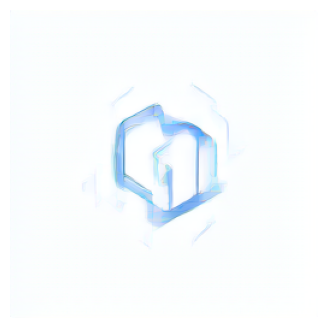

In [8]:
import torch
import gc
import matplotlib.pyplot as plt

# تنظيف قبل التوليد
gc.collect()
torch.cuda.empty_cache()

print("📊 ذاكرة GPU قبل التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# تقليل استهلاك الذاكرة أثناء الانتشار
try:
    pipe.enable_attention_slicing("max")
    print("✅ Attention slicing مفعّل")
except Exception as e:
    print(f"⚠️ Attention slicing فشل: {e}")

try:
    pipe.enable_vae_tiling()
    print("✅ VAE tiling مفعّل")
except Exception as e:
    print(f"⚠️ VAE tiling فشل: {e}")

prompt = (
    "minimalist logo, professional corporate branding, "
    "flat vector design, geometric icon, clean background, "
    "no text, no cartoon, no mascot"
)

print("\n⏳ جاري توليد صورة اختبار 256x256، 4 خطوات فقط...")

with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        width=256,
        height=256,
        num_inference_steps=4,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]

image.save("qwen_test_256.png")

print("✅ تم حفظ الصورة: qwen_test_256.png")

print("\n📊 ذاكرة GPU بعد التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

📊 ذاكرة GPU قبل التوليد:
   allocated: 11.43 GB
   reserved:  11.46 GB

⏳ جاري توليد صورة 512x512، 10 خطوات...


  0%|          | 0/10 [00:00<?, ?it/s]

✅ تم حفظ الصورة: qwen_test_512.png

📊 ذاكرة GPU بعد التوليد:
   allocated: 11.43 GB
   reserved:  13.73 GB


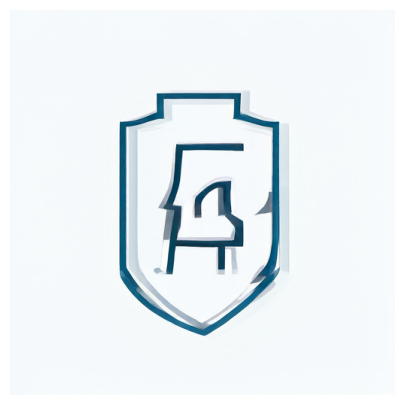

In [9]:
import torch
import gc
import matplotlib.pyplot as plt

gc.collect()
torch.cuda.empty_cache()

print("📊 ذاكرة GPU قبل التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

prompt = (
    "minimalist logo, professional corporate branding, "
    "flat vector design, geometric icon, clean background, "
    "no text, no cartoon, no mascot"
)

print("\n⏳ جاري توليد صورة 512x512، 10 خطوات...")

with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        width=512,
        height=512,
        num_inference_steps=10,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]

image.save("qwen_test_512.png")

print("✅ تم حفظ الصورة: qwen_test_512.png")

print("\n📊 ذاكرة GPU بعد التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

📊 ذاكرة GPU قبل التوليد:
   allocated: 11.43 GB
   reserved:  11.46 GB

⏳ جاري توليد صورة 512x512، 20 خطوة...


  0%|          | 0/20 [00:00<?, ?it/s]

✅ تم حفظ الصورة: qwen_test_512_20steps.png

📊 ذاكرة GPU بعد التوليد:
   allocated: 11.43 GB
   reserved:  13.73 GB


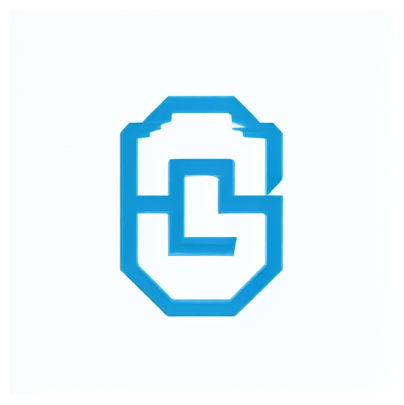

In [15]:
import torch
import gc
import matplotlib.pyplot as plt

gc.collect()
torch.cuda.empty_cache()

print("📊 ذاكرة GPU قبل التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

prompt = (
    "minimalist logo, professional corporate branding, "
    "flat vector design, geometric icon, clean background, "
    "no text, no cartoon, no mascot"
)

print("\n⏳ جاري توليد صورة 512x512، 20 خطوة...")

with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        negative_prompt="",
        true_cfg_scale=4.0,
        width=512,
        height=512,
        num_inference_steps=20,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]

image.save("qwen_test_512_20steps.png")

print("✅ تم حفظ الصورة: qwen_test_512_20steps.png")

print("\n📊 ذاكرة GPU بعد التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

📊 ذاكرة GPU قبل التوليد:
   allocated: 11.43 GB
   reserved:  11.46 GB

⏳ جاري توليد صورة 512x512، 30 خطوة، برومبت محدد...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ تم حفظ الصورة: qwen_test_512_30steps_specific.png

📊 ذاكرة GPU بعد التوليد:
   allocated: 11.43 GB
   reserved:  13.62 GB


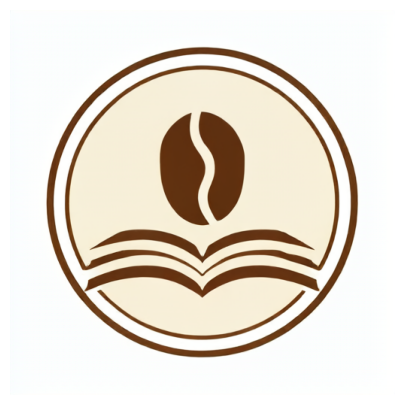

In [16]:
import torch
import gc
import matplotlib.pyplot as plt

gc.collect()
torch.cuda.empty_cache()

print("📊 ذاكرة GPU قبل التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

prompt = (
    "A minimalist logo for a university coffee shop, "
    "circular badge design, coffee bean and steam subtly forming an open book, "
    "warm brown and cream color palette, flat vector style, "
    "clean white background, centered composition, professional brand mark, "
    "geometric shapes, simple iconic symbol, no lettering, no text, no watermark"
)

negative_prompt = (
    "text, letters, words, realistic photo, 3d render, gradient, shadow, "
    "complex background, cartoon, mascot, cluttered, noisy, blurry"
)

print("\n⏳ جاري توليد صورة 512x512، 30 خطوة، برومبت محدد...")

with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        true_cfg_scale=4.0,
        width=512,
        height=512,
        num_inference_steps=30,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]

image.save("qwen_test_512_30steps_specific.png")

print("✅ تم حفظ الصورة: qwen_test_512_30steps_specific.png")

print("\n📊 ذاكرة GPU بعد التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
✅ Attention slicing مفعّل
📋 عدد البريفات: 5

🎨 بدء توليد 5 شعارات...

⏳ [BR001] coffee
   Prompt: simple geometric coffee-inspired symbol, professional corporate branding, flat vector design, Adobe Illustrator style, g...


  0%|          | 0/30 [00:00<?, ?it/s]

   ✅ تم الحفظ: QWEN_BR001_512_30.png
   📊 GPU allocated: 11.43 GB
   📊 GPU reserved:  11.46 GB
⏳ [BR002] healthy snacks
   Prompt: simple fruit or leaf-inspired symbol, professional corporate branding, flat vector design, Adobe Illustrator style, geom...


  0%|          | 0/30 [00:00<?, ?it/s]

   ✅ تم الحفظ: QWEN_BR002_512_30.png
   📊 GPU allocated: 11.43 GB
   📊 GPU reserved:  11.46 GB
⏳ [BR003] specialty bakery
   Prompt: hand-drawn bakery symbol with a handcrafted feel, professional corporate branding, flat vector design, Adobe Illustrator...


...

   ✅ تم الحفظ: QWEN_BR003_512_30.png
   📊 GPU allocated: 11.43 GB
   📊 GPU reserved:  11.46 GB
⏳ [BR004] specialty tea
   Prompt: elegant botanical tea-inspired mark, professional corporate branding, flat vector design, Adobe Illustrator style, geome...


  0%|          | 0/30 [00:00<?, ?it/s]

   ✅ تم الحفظ: QWEN_BR004_512_30.png
   📊 GPU allocated: 11.43 GB
   📊 GPU reserved:  11.46 GB
⏳ [BR005] street food
   Prompt: bold simplified food symbol with dynamic shapes, professional corporate branding, flat vector design, Adobe Illustrator ...


  0%|          | 0/30 [00:00<?, ?it/s]

   ✅ تم الحفظ: QWEN_BR005_512_30.png
   📊 GPU allocated: 11.43 GB
   📊 GPU reserved:  11.46 GB

✅ انتهى التوليد الجزئي أو الكامل.


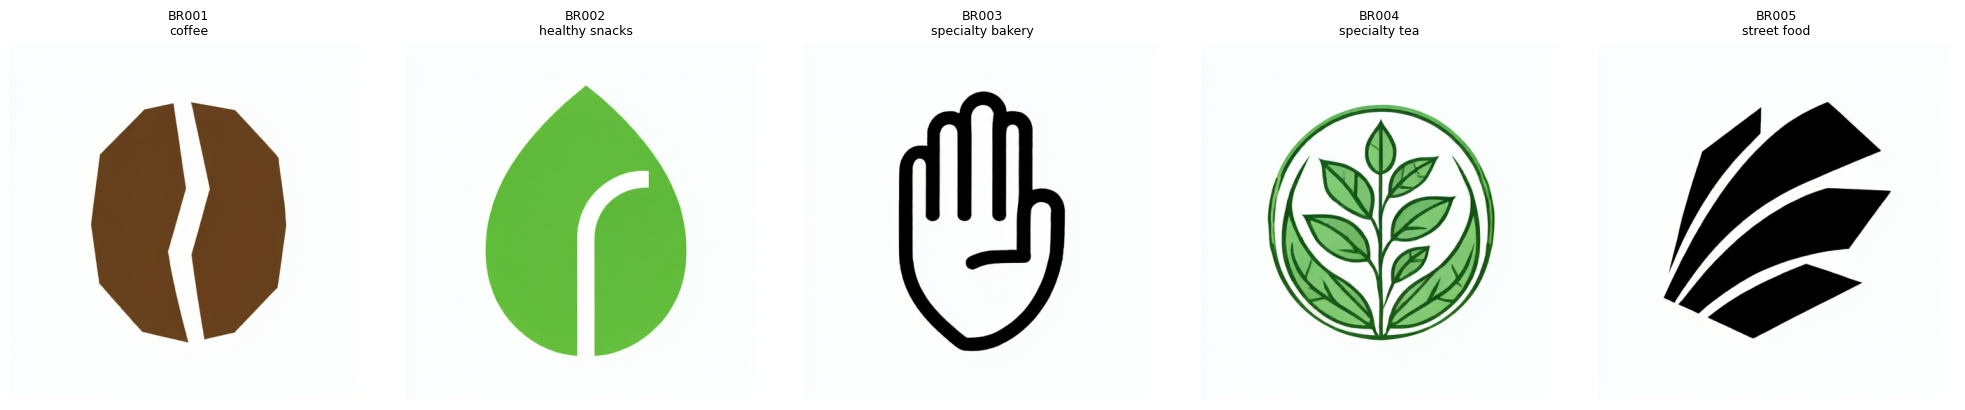


📸 تم حفظ صورة المقارنة: qwen_5_briefs_512_30.png


In [17]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

import torch
import gc
import os
import requests
import matplotlib.pyplot as plt
from PIL import Image

# تنظيف الذاكرة قبل البدء
gc.collect()
torch.cuda.empty_cache()

# تفعيل تقليل استهلاك الذاكرة إن أمكن
try:
    pipe.enable_attention_slicing("max")
    print("✅ Attention slicing مفعّل")
except Exception as e:
    print(f"⚠️ Attention slicing فشل: {e}")

# تحميل أول 5 بريفات
url = "https://raw.githubusercontent.com/maram-elaian/brandora/main/data/test_briefs.json"
briefs = requests.get(url).json()
test_briefs = briefs[:5]

print(f"📋 عدد البريفات: {len(test_briefs)}")

# نفس برومبت FLUX لتبقى المقارنة موحدة
def brief_to_image_prompt(b):
    return (
        f"{b['logo_direction']}, professional corporate branding, "
        f"flat vector design, Adobe Illustrator style, geometric, "
        f"minimalist icon, clean background, no text, no cartoon, no mascot"
    )

negative_prompt = (
    "text, letters, words, watermark, signature, realistic photo, "
    "3d render, gradient, shadow, complex background, cartoon, mascot, "
    "cluttered, blurry, noisy"
)

generated_files = []

print("\n🎨 بدء توليد 5 شعارات...\n")

for brief in test_briefs:
    prompt = brief_to_image_prompt(brief)

    print(f"⏳ [{brief['id']}] {brief['industry']}")
    print(f"   Prompt: {prompt[:120]}...")

    try:
        with torch.inference_mode():
            image = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                true_cfg_scale=4.0,
                width=512,
                height=512,
                num_inference_steps=30,
                generator=torch.Generator("cuda").manual_seed(42),
            ).images[0]

        filename = f"QWEN_{brief['id']}_512_30.png"
        image.save(filename)

        generated_files.append({
            "id": brief["id"],
            "industry": brief["industry"],
            "file": filename
        })

        print(f"   ✅ تم الحفظ: {filename}")

        # تنظيف بعد كل صورة
        del image
        gc.collect()
        torch.cuda.empty_cache()

        print(f"   📊 GPU allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
        print(f"   📊 GPU reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

    except Exception as e:
        print(f"   ❌ فشل: {str(e)[:200]}")
        print("   ⏹️ توقفت الحلقة لحماية الذاكرة.")
        break

print("\n✅ انتهى التوليد الجزئي أو الكامل.")

# عرض النتائج
if generated_files:
    n = len(generated_files)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, item in zip(axes, generated_files):
        img = Image.open(item["file"])
        ax.imshow(img)
        ax.set_title(f"{item['id']}\n{item['industry']}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("qwen_5_briefs_512_30.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n📸 تم حفظ صورة المقارنة: qwen_5_briefs_512_30.png")

else:
    print("⚠️ لم يتم توليد أي صورة.")

In [19]:
import torch

vae = pipe.vae

print("📊 ذاكرة GPU قبل الفحص:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

print("\n🔍 خصائص الـ VAE المرتبطة بتقليل الذاكرة:")

relevant_methods = [
    name for name in dir(vae)
    if any(keyword in name.lower() for keyword in [
        "tile", "tiling", "slice", "slicing", "offload", "compile"
    ])
]

print(relevant_methods)

print("\nهل يدعم enable_tiling؟", hasattr(vae, "enable_tiling"))
print("هل يدعم enable_slicing؟", hasattr(vae, "enable_slicing"))
print("هل يدعم disable_tiling؟", hasattr(vae, "disable_tiling"))
print("هل يدعم disable_slicing؟", hasattr(vae, "disable_slicing"))

try:
    first_param = next(vae.parameters())
    print("\n📄 جهاز أول بارامتر في الـ VAE:", first_param.device)
    print("📄 نوع أول بارامتر في الـ VAE:", first_param.dtype)
except Exception as e:
    print("\n⚠️ لم أستطع قراءة أول بارامتر من الـ VAE:", e)

📊 ذاكرة GPU قبل الفحص:
   allocated: 14.08 GB
   reserved:  14.89 GB

🔍 خصائص الـ VAE المرتبطة بتقليل الذاكرة:
['_compiled_call_impl', '_group_offload_block_modules', '_supports_group_offloading', 'compile', 'compile_repeated_blocks', 'disable_slicing', 'disable_tiling', 'enable_group_offload', 'enable_slicing', 'enable_tiling', 'tile_sample_min_height', 'tile_sample_min_width', 'tile_sample_stride_height', 'tile_sample_stride_width', 'tiled_decode', 'tiled_encode', 'use_slicing', 'use_tiling']

هل يدعم enable_tiling؟ True
هل يدعم enable_slicing؟ True
هل يدعم disable_tiling؟ True
هل يدعم disable_slicing؟ True

📄 جهاز أول بارامتر في الـ VAE: cuda:0
📄 نوع أول بارامتر في الـ VAE: torch.float16


In [20]:
import torch
import gc

vae = pipe.vae

print("📊 ذاكرة GPU قبل التنظيف وتفعيل Tiling:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# تفعيل فك الـ VAE على أجزاء
vae.enable_tiling()
vae.enable_slicing()

# تقليل حجم الـ tile لتوفير ذاكرة أكثر
vae.tile_sample_min_height = 128
vae.tile_sample_min_width = 128
vae.tile_sample_stride_height = 64
vae.tile_sample_stride_width = 64

# تنظيف أي caches داخلية قد تكون بقيت من المحاولة الفاشلة
for attr in ["_feat_map", "_conv_idx", "_cache"]:
    if hasattr(vae, attr):
        try:
            setattr(vae, attr, None)
        except Exception:
            pass

if hasattr(vae, "clear_cache"):
    try:
        vae.clear_cache()
        print("✅ تم تنظيف VAE cache")
    except Exception as e:
        print(f"⚠️ clear_cache فشل: {e}")

gc.collect()
torch.cuda.empty_cache()

print("\n✅ تم تفعيل VAE tiling/slicing")
print("use_tiling:", vae.use_tiling)
print("use_slicing:", vae.use_slicing)
print("tile_sample_min_height:", vae.tile_sample_min_height)
print("tile_sample_min_width:", vae.tile_sample_min_width)
print("tile_sample_stride_height:", vae.tile_sample_stride_height)
print("tile_sample_stride_width:", vae.tile_sample_stride_width)

print("\n📊 ذاكرة GPU بعد التنظيف وتفعيل Tiling:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

📊 ذاكرة GPU قبل التنظيف وتفعيل Tiling:
   allocated: 14.08 GB
   reserved:  14.89 GB
✅ تم تنظيف VAE cache

✅ تم تفعيل VAE tiling/slicing
use_tiling: True
use_slicing: True
tile_sample_min_height: 128
tile_sample_min_width: 128
tile_sample_stride_height: 64
tile_sample_stride_width: 64

📊 ذاكرة GPU بعد التنظيف وتفعيل Tiling:
   allocated: 14.08 GB
   reserved:  14.89 GB


In [21]:
import sys
import gc
import torch

print("📊 ذاكرة GPU قبل التنظيف العميق:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# حذف أي متغيرات ممكن تكون بقيت من محاولات سابقة
possible_leftovers = [
    "image",
    "images",
    "latents",
    "prompt_embeds",
    "prompt_embeds_mask",
    "negative_prompt_embeds",
    "negative_prompt_embeds_mask",
    "input_images",
    "outputs",
    "generated_files",
]

for name in possible_leftovers:
    if name in globals():
        try:
            del globals()[name]
            print(f" تم حذف المتغير: {name}")
        except Exception as e:
            print(f"⚠️ فشل حذف {name}: {e}")

# تنظيف مراجع الاستثناء الأخيرة، لأنها قد تحتفظ بـ CUDA tensors
for attr in ["last_type", "last_value", "last_traceback"]:
    if hasattr(sys, attr):
        try:
            setattr(sys, attr, None)
            print(f"🧹 تم تنظيف sys.{attr}")
        except Exception as e:
            print(f"⚠️ فشل تنظيف sys.{attr}: {e}")

# تنظيف IPython/Jupyter traceback cache إن وُجد
try:
    ip = get_ipython()
    if hasattr(ip, "last_exception"):
        ip.last_exception = None
        print("🧹 تم تنظيف IPython last_exception")
except Exception:
    pass

gc.collect()
torch.cuda.empty_cache()

print("\n📊 ذاكرة GPU بعد التنظيف العميق:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

📊 ذاكرة GPU قبل التنظيف العميق:
   allocated: 14.08 GB
   reserved:  14.89 GB
 تم حذف المتغير: generated_files
🧹 تم تنظيف sys.last_type
🧹 تم تنظيف sys.last_value
🧹 تم تنظيف sys.last_traceback

📊 ذاكرة GPU بعد التنظيف العميق:
   allocated: 14.08 GB
   reserved:  14.89 GB


In [18]:
import torch
import gc
import matplotlib.pyplot as plt

gc.collect()
torch.cuda.empty_cache()

print("📊 ذاكرة GPU قبل التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

prompt = (
    "simple geometric coffee-inspired symbol, professional corporate branding, "
    "flat vector design, Adobe Illustrator style, geometric, "
    "minimalist icon, clean background, no text, no cartoon, no mascot"
)

negative_prompt = (
    "text, letters, words, watermark, signature, realistic photo, "
    "3d render, gradient, shadow, complex background, cartoon, mascot, "
    "cluttered, blurry, noisy"
)

print("\n⏳ جاري توليد صورة اختبار 768x768، 30 خطوة...")

with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        true_cfg_scale=4.0,
        width=768,
        height=768,
        num_inference_steps=30,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]

image.save("qwen_test_768_30.png")

print("✅ تم حفظ الصورة: qwen_test_768_30.png")

print("\n📊 ذاكرة GPU بعد التوليد:")
print(f"   allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"   reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

📊 ذاكرة GPU قبل التوليد:
   allocated: 11.43 GB
   reserved:  11.46 GB

⏳ جاري توليد صورة اختبار 768x768، 30 خطوة...


  0%|          | 0/30 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 648.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 576.81 MiB is free. Including non-PyTorch memory, this process has 14.00 GiB memory in use. Of the allocated memory 13.12 GiB is allocated by PyTorch, and 767.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)